# 02 · Generative Adversarial Networks

**Generative Modelling for HEP** — notebook 2 of 6.

A GAN is a two-player game: a **generator** turns noise into fake samples, and a
**discriminator** (or, for WGAN, a **critic**) tries to tell real from fake. They
train against each other until the fakes look real. It is powerful but famously
temperamental — the headline failure is **mode collapse**, where the generator
gives up on diversity and produces the *same* output over and over.

We build intuition on **QuickDraw doodles** 🖊️: first a vanilla GAN, then we
*deliberately* drive it into mode collapse, then we *fix* it with **WGAN-GP**.
Finally we carry the idea to physics with a **point-cloud jet GAN** and watch
our recurring **jet-mass** spine — where the GAN nails the bulk but drops the
high-mass tail.

> You complete the cells marked **Exercise**. Everything else runs as-is.

In [1]:
%load_ext cadence
# Loads the cadence magics + the input transformer that comments out
# `# cadence:starter` regions, so the scaffold placeholders never run.

## Setup

In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

import sys; sys.path.insert(0, "..")
from src.seeds import set_seed
from src.train import get_device, to_loader, train
from src.data import load_quickdraw_local, load_jetnet
from src.gnn import DeepSetsEncoder, DeepSetsDecoder
from src.jets import JetStandardizer
from src.jetmass import jet_mass, plot_jet_mass, jet_mass_w1, plot_jets, plot_jet_overlay

SEED = 0
NOISE_DIM = 32
# GANs need many epochs to draw recognisable doodles. 20 is a usable default on
# GPU (~1-2 min/training); on a CPU drop to ~5 (the *concepts* — adversarial
# loss, mode collapse, the WGAN-GP fix — all still come through, the samples
# just stay rough); on GPU push to 50+ for crisp doodles, or load a checkpoint.
EPOCHS = 5
BATCH = 128
set_seed(SEED)
device = get_device()
print(f"device={device}  noise_dim={NOISE_DIM}  epochs={EPOCHS}")

device=cpu  noise_dim=32  epochs=5


## Part A · A GAN on QuickDraw doodles

We load real Google **QuickDraw** bitmaps at 28×28 — four categories
(cat / fish / apple / bicycle), which double as the *modes* we'll track for mode
collapse. We use a small **DCGAN** (convolutional) generator and discriminator —
conv nets draw far sharper doodles than a plain fully-connected net.

[data] loaded 4000 QuickDraw doodles from /Users/liv/teaching/ml4hep/gen-hep-notebooks/data/quickdraw.npz (cat=1000, fish=1000, apple=1000, bicycle=1000)
images: (1, 28, 28) | modes (categories): 4


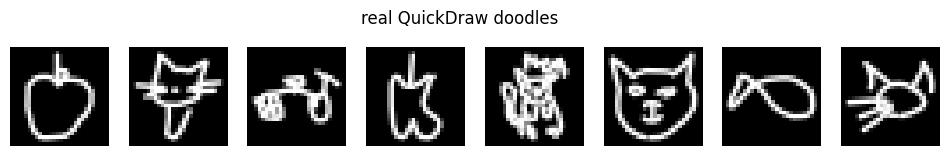

Generator params: 339521


In [3]:
images, mode_labels = load_quickdraw_local(n=4000)         # (N,1,28,28), real doodles
X = torch.as_tensor(images, dtype=torch.float32)
img_loader = to_loader(X, batch_size=BATCH)
IMG_SHAPE = tuple(X.shape[1:])                             # (1, 28, 28)
IMG_DIM = int(np.prod(IMG_SHAPE))
N_MODES = int(len(np.unique(mode_labels)))                # categories -> "modes"
print("images:", IMG_SHAPE, "| modes (categories):", N_MODES)


class Generator(nn.Module):
    """DCGAN generator: noise -> 7x7 feature map -> upsample to 28x28."""
    def __init__(self, noise=NOISE_DIM):
        super().__init__()
        self.fc = nn.Linear(noise, 128 * 7 * 7)
        self.net = nn.Sequential(
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.BatchNorm2d(64), nn.ReLU(),  # 7 -> 14
            nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Sigmoid())                     # 14 -> 28

    def forward(self, z):
        return self.net(self.fc(z).view(-1, 128, 7, 7))


class Discriminator(nn.Module):
    """DCGAN discriminator: 28x28 -> conv downsample -> logit."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2),       # 28 -> 14
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2),     # 14 -> 7
            nn.Flatten(), nn.Linear(128 * 7 * 7, 1))            # logit (BCEWithLogits)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def sample_noise(n):
    return torch.randn(n, NOISE_DIM, device=device)


# A peek at the real doodles we're trying to imitate.
fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for ax, im in zip(axes, X[np.random.permutation(len(X))[:8]]):
    ax.imshow(im.squeeze(0).numpy(), cmap="gray"); ax.axis("off")
fig.suptitle("real QuickDraw doodles"); plt.show()
print("Generator params:", sum(p.numel() for p in Generator().parameters()))

### Exercise 1 — The adversarial loss

A vanilla (non-saturating) GAN alternates two updates per batch:

* **discriminator**: push real → 1, fake → 0
  $\;\mathcal{L}_D = \text{BCE}(D(x),1) + \text{BCE}(D(G(z)),0)$
* **generator**: fool the discriminator
  $\;\mathcal{L}_G = \text{BCE}(D(G(z)),1)$

Fill in the two loss terms in `gan_step`, run a few epochs of the manual
training loop (provided), and report the **final discriminator loss** as
`final_d_loss` (a number).

In [4]:
# cadence:starter
bce = nn.BCEWithLogitsLoss()

def gan_step(G, D, real, opt_g, opt_d):
    n = real.shape[0]
    ones, zeros = torch.ones(n, device=device), torch.zeros(n, device=device)

    # --- discriminator: real -> 1, fake -> 0 ---
    fake = G(sample_noise(n)).detach()
    d_loss = ...
    opt_d.zero_grad(); d_loss.backward(); opt_d.step()

    # --- generator: fool D (fake -> 1) ---
    gen = G(sample_noise(n))
    g_loss = ...
    opt_g.zero_grad(); g_loss.backward(); opt_g.step()
    return float(d_loss), float(g_loss)

# Training loop (provided) — runs once you've filled the two losses above.
set_seed(SEED)
G = Generator().to(device)
D = Discriminator().to(device)
opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_hist = []
for _ in range(EPOCHS):
    epoch_d = [gan_step(G, D, real.to(device), opt_g, opt_d)[0] for (real,) in img_loader]
    d_hist.append(float(np.mean(epoch_d)))
final_d_loss = round(d_hist[-1], 3)
# cadence:end

bce = nn.BCEWithLogitsLoss()

def gan_step(G, D, real, opt_g, opt_d):
    n = real.shape[0]
    ones, zeros = torch.ones(n, device=device), torch.zeros(n, device=device)

    fake = G(sample_noise(n)).detach()
    d_loss = bce(D(real), ones) + bce(D(fake), zeros)
    opt_d.zero_grad(); d_loss.backward(); opt_d.step()

    gen = G(sample_noise(n))
    g_loss = bce(D(gen), ones)
    opt_g.zero_grad(); g_loss.backward(); opt_g.step()
    return float(d_loss), float(g_loss)

set_seed(SEED)
G = Generator().to(device)
D = Discriminator().to(device)
opt_g = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_d = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_hist = []
for _ in range(EPOCHS):
    epoch_d = [gan_step(G, D, real.to(device), opt_g, opt_d)[0] for (real,) in img_loader]
    d_hist.append(float(np.mean(epoch_d)))
final_d_loss = round(d_hist[-1], 3)
print("final discriminator loss:", final_d_loss)

final_d_loss

final discriminator loss: 0.688


0.688

### Does it draw doodles?

Real doodles (top) vs the vanilla GAN's samples (bottom) after training. At a few
epochs they're rough; with more epochs (bump `EPOCHS`) recognisable shapes
emerge. GANs are finicky and slow to train — that's part of today's lesson, and
why we'll fix the failure modes next.

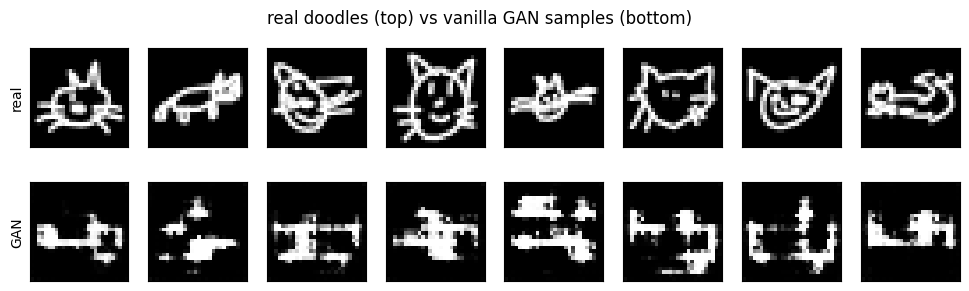

In [5]:
G.eval()
with torch.no_grad():
    gen = G(sample_noise(8)).cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for j in range(8):
    axes[0, j].imshow(X[j, 0], cmap="gray"); axes[0, j].set_xticks([]); axes[0, j].set_yticks([])
    axes[1, j].imshow(gen[j, 0], cmap="gray"); axes[1, j].set_xticks([]); axes[1, j].set_yticks([])
axes[0, 0].set_ylabel("real"); axes[1, 0].set_ylabel("GAN")
fig.suptitle("real doodles (top) vs vanilla GAN samples (bottom)")
plt.show()

## Part B · Mode collapse — "the GAN only draws one thing"

Now we *induce* the classic pathology. By over-training the generator relative to
the discriminator (many G steps per D step) on a tiny noise budget, the generator
learns to dump all its mass on whichever mode currently fools D best — it stops
covering the others. We retrain a deliberately collapse-prone GAN for you below.

In [8]:
# A collapse-prone training schedule: hammer the generator, starve the critic.
set_seed(SEED)
G_collapse = Generator().to(device)
D_collapse = Discriminator().to(device)
og = torch.optim.Adam(G_collapse.parameters(), lr=2e-3, betas=(0.5, 0.999))
od = torch.optim.Adam(D_collapse.parameters(), lr=5e-5, betas=(0.5, 0.999))
bce = nn.BCEWithLogitsLoss()
for _ in range(EPOCHS):
    for (real,) in img_loader:
        real = real.to(device)
        n = real.shape[0]
        # one stingy discriminator step
        fake = G_collapse(sample_noise(n)).detach()
        dl = bce(D_collapse(real), torch.ones(n, device=device)) + \
             bce(D_collapse(fake), torch.zeros(n, device=device))
        od.zero_grad(); dl.backward(); od.step()
        # FIVE greedy generator steps -> collapse toward one mode
        for _g in range(5):
            gen = G_collapse(sample_noise(n))
            gl = bce(D_collapse(gen), torch.ones(n, device=device))
            og.zero_grad(); gl.backward(); og.step()


def nearest_mode(samples, refs, ref_modes):
    """Assign each generated sample to the data mode of its nearest real
    neighbour (a tiny coverage proxy)."""
    s = samples.reshape(len(samples), -1)
    r = refs.reshape(len(refs), -1)
    d = torch.cdist(s, r)                       # (n_samples, n_refs)
    nn_idx = d.argmin(dim=1).cpu().numpy()
    return ref_modes[nn_idx]


print("collapse-prone GAN trained;  helper `nearest_mode` ready")

collapse-prone GAN trained;  helper `nearest_mode` ready


### Exercise 2 — Measure the mode collapse

Generate 512 doodles from the collapsed generator, snap each to the **nearest
real-data mode** (use the provided `nearest_mode`), and count how many of the
`N_MODES` data modes the generator still covers. A healthy GAN covers all of
them; a collapsed one covers just one or two. Return the integer count as
`modes_covered` (a number).

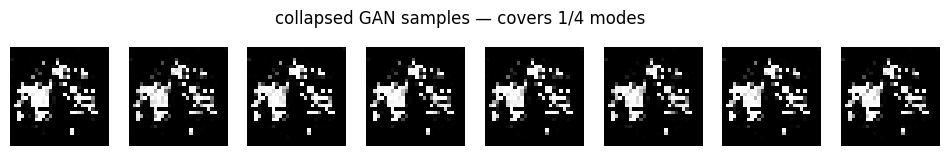

modes covered: 1 of 4


1

In [9]:
# cadence:starter
G_collapse.eval()
with torch.no_grad():
    samples = G_collapse(sample_noise(512))
    refs = X[:1024].to(device)
    ref_modes = mode_labels[:1024]
    assigned = nearest_mode(samples, refs, ref_modes)   # mode id per sample
    # how many distinct data modes appear among the generated samples?
    modes_covered = ...
# cadence:end

G_collapse.eval()
with torch.no_grad():
    samples = G_collapse(sample_noise(512))
    refs = X[:1024].to(device)
    ref_modes = mode_labels[:1024]
    assigned = nearest_mode(samples, refs, ref_modes)
    modes_covered = int(len(np.unique(assigned)))

fig, axes = plt.subplots(1, 8, figsize=(12, 1.8))
for ax, im in zip(axes, samples[:8].cpu()):
    ax.imshow(im.squeeze(0).numpy(), cmap="gray"); ax.axis("off")
fig.suptitle(f"collapsed GAN samples — covers {modes_covered}/{N_MODES} modes")
plt.show()
print("modes covered:", modes_covered, "of", N_MODES)

modes_covered

## Part C · Fixing it with WGAN-GP

The Wasserstein GAN replaces the BCE classifier with a **critic** that scores
real vs fake, trained to be **1-Lipschitz** via a **gradient penalty** on samples
interpolated between real and fake:

$$\text{GP} = \lambda\,\mathbb{E}_{\hat x}\big[(\lVert\nabla_{\hat x} C(\hat x)\rVert_2 - 1)^2\big],
\qquad \hat x = \epsilon x + (1-\epsilon)\tilde x .$$

This gives smooth, informative gradients everywhere, which is exactly what kills
mode collapse. We provide a critic and a WGAN training loop; you implement the
gradient penalty.

In [10]:
class Critic(nn.Module):
    """Like the discriminator but outputs a raw score (no sigmoid), and NO
    BatchNorm — batch stats would break the per-sample gradient penalty."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1), nn.LeakyReLU(0.2),       # 28 -> 14
            nn.Conv2d(64, 128, 4, 2, 1), nn.LeakyReLU(0.2),     # 14 -> 7
            nn.Flatten(), nn.Linear(128 * 7 * 7, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


print("Critic ready (no sigmoid — it outputs a real-valued score)")

Critic ready (no sigmoid — it outputs a real-valued score)


### Exercise 3 — The gradient penalty

Implement `gradient_penalty(C, real, fake)`: sample a per-example $\epsilon$,
form the interpolates $\hat x = \epsilon x + (1-\epsilon)\tilde x$, take the
gradient of $C(\hat x)$ w.r.t. $\hat x$ with
`torch.autograd.grad(..., create_graph=True)`, and return
$\lambda\,\overline{(\lVert\nabla\rVert_2 - 1)^2}$ with $\lambda=10$.

The cell sanity-checks your penalty on one **seeded** batch (so everyone gets the
same value) — return it as `gp_value` (a positive number). The next cell uses
your function to train the fix.

In [11]:
# cadence:starter
def gradient_penalty(C, real, fake, lam=10.0):
    n = real.shape[0]
    eps = torch.rand(n, *([1] * (real.dim() - 1)), device=device)
    # interpolate between real and fake, and require gradients on it:
    x_hat = ...
    x_hat.requires_grad_(True)
    score = C(x_hat)
    grad = torch.autograd.grad(
        outputs=score, inputs=x_hat, grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True)[0].reshape(n, -1)
    # penalty: lam * mean((||grad||_2 - 1)^2)
    gp = ...
    return gp

set_seed(SEED)                                # so gp_value is reproducible
_real = X[:64].to(device)
_fake = Generator().to(device)(sample_noise(64))
gp_value = round(float(gradient_penalty(Critic().to(device), _real, _fake)), 3)
# cadence:end

def gradient_penalty(C, real, fake, lam=10.0):
    n = real.shape[0]
    eps = torch.rand(n, *([1] * (real.dim() - 1)), device=device)
    x_hat = eps * real + (1 - eps) * fake
    x_hat.requires_grad_(True)
    score = C(x_hat)
    grad = torch.autograd.grad(
        outputs=score, inputs=x_hat, grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True)[0].reshape(n, -1)
    gp = lam * ((grad.norm(2, dim=1) - 1) ** 2).mean()
    return gp

set_seed(SEED)
_real = X[:64].to(device)
_fake = Generator().to(device)(sample_noise(64))
gp_value = round(float(gradient_penalty(Critic().to(device), _real, _fake)), 3)
print("gradient penalty on a seeded batch:", gp_value)

gp_value

gradient penalty on a seeded batch: 8.211


8.211

### The fix in action

Now we train a WGAN-GP using **your** `gradient_penalty`, then re-measure mode
coverage — it should recover the modes the collapsed GAN abandoned.

In [12]:
set_seed(SEED)
Gw = Generator().to(device)
Cw = Critic().to(device)
ogw = torch.optim.Adam(Gw.parameters(), lr=1e-4, betas=(0.0, 0.9))
ocw = torch.optim.Adam(Cw.parameters(), lr=1e-4, betas=(0.0, 0.9))
N_CRITIC = 3
for _ in range(EPOCHS):
    for (real,) in img_loader:
        real = real.to(device); n = real.shape[0]
        for _c in range(N_CRITIC):
            fake = Gw(sample_noise(n)).detach()
            c_loss = Cw(fake).mean() - Cw(real).mean() + gradient_penalty(Cw, real, fake)
            ocw.zero_grad(); c_loss.backward(); ocw.step()
        gen = Gw(sample_noise(n))
        ogw.zero_grad(); (-Cw(gen).mean()).backward(); ogw.step()

Gw.eval()
with torch.no_grad():
    assigned = nearest_mode(Gw(sample_noise(512)), X[:1024].to(device), mode_labels[:1024])
    modes_covered_wgan = int(len(np.unique(assigned)))
print(f"WGAN-GP recovered {modes_covered_wgan}/{N_MODES} modes")

WGAN-GP recovered 2/4 modes


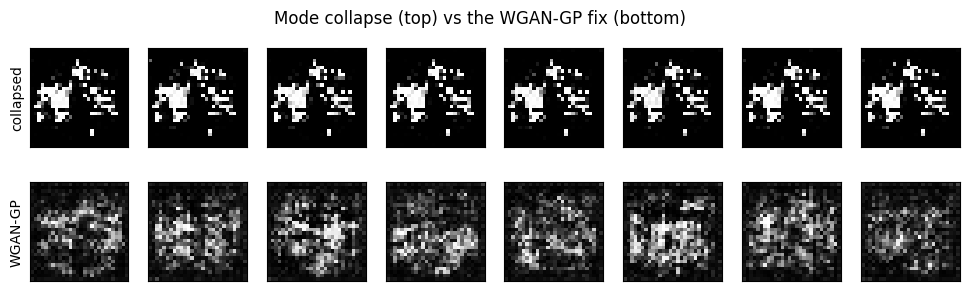

In [13]:
# Before vs after: collapsed GAN (top) piles onto a mode or two; WGAN-GP (bottom)
# spreads back across the categories.
G_collapse.eval(); Gw.eval()
with torch.no_grad():
    coll = G_collapse(sample_noise(8)).cpu()
    fixed = Gw(sample_noise(8)).cpu()
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for row, (batch, name) in enumerate([(coll, "collapsed"), (fixed, "WGAN-GP")]):
    for j in range(8):
        axes[row, j].imshow(batch[j, 0], cmap="gray")
        axes[row, j].set_xticks([]); axes[row, j].set_yticks([])
    axes[row, 0].set_ylabel(name)
fig.suptitle("Mode collapse (top) vs the WGAN-GP fix (bottom)")
plt.show()

## Part D · A point-cloud jet GAN

Now the physics. Jets are **point clouds**, so we build a permutation-respecting
GAN: a **DeepSets generator** (`DeepSetsDecoder`: noise → 30 particles) and a
**DeepSets critic** (`DeepSetsEncoder` → score). We train it WGAN-GP-style and
overlay the **jet-mass spine** against real gluon jets. GANs are sharp in the
bulk but, like the VAE, tend to **drop the high-mass tail**.

[data] loaded 5000 real JetNet 'g' jets
gluon jets: (5000, 30, 3) | standardized for training


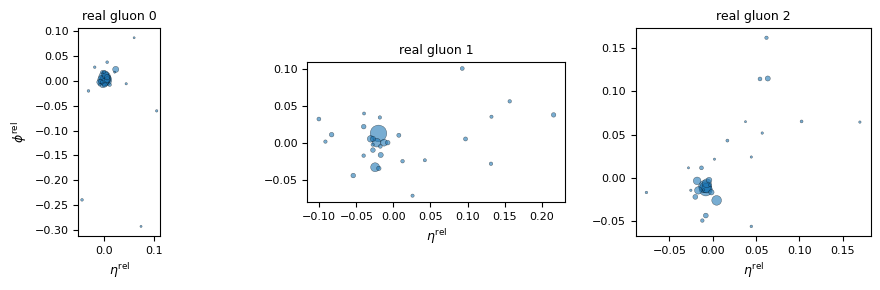

JetGenerator params: 27843


In [14]:
gluon = load_jetnet("g", num_particles=30, max_jets=5000)   # physical jets
JET_SHAPE = gluon.shape[1:]                 # (30, 3)
# Standardize (log-pt + z-score) so the GAN targets the right per-feature scales
# and the pt concentration; samples are inverse-transformed back to physical
# jets before the mass plot / displays.
jet_std = JetStandardizer().fit(gluon)
jet_loader = to_loader(jet_std.transform(gluon), batch_size=BATCH)
print("gluon jets:", gluon.shape, "| standardized for training")


class JetGenerator(nn.Module):
    """noise -> latent -> DeepSets decoder -> (B, 30, 3) particle cloud."""
    def __init__(self, noise=NOISE_DIM, n_particles=30):
        super().__init__()
        self.lift = nn.Sequential(nn.Linear(noise, 64), nn.ReLU(), nn.Linear(64, 32))
        self.dec = DeepSetsDecoder(latent=32, n_particles=n_particles)

    def forward(self, z):
        return self.dec(self.lift(z))


class JetCritic(nn.Module):
    """DeepSets encoder -> scalar score (1-Lipschitz target)."""
    def __init__(self):
        super().__init__()
        self.enc = DeepSetsEncoder(in_features=3, hidden=128, latent=64,
                                   mask_padding=False)   # standardized jets
        self.head = nn.Linear(64, 1)

    def forward(self, x):
        return self.head(self.enc(x)).squeeze(-1)


def jet_gradient_penalty(C, real, fake, lam=10.0):
    n = real.shape[0]
    eps = torch.rand(n, 1, 1, device=device)
    x_hat = (eps * real + (1 - eps) * fake).requires_grad_(True)
    score = C(x_hat)
    grad = torch.autograd.grad(
        outputs=score, inputs=x_hat,
        grad_outputs=torch.ones_like(score),
        create_graph=True, retain_graph=True)[0]
    grad = grad.reshape(n, -1)
    return lam * ((grad.norm(2, dim=1) - 1) ** 2).mean()


# See the real jets as event displays before generating any.
plot_jets(gluon[:3], titles=[f"real gluon {i}" for i in range(3)]); plt.show()
print("JetGenerator params:", sum(p.numel() for p in JetGenerator().parameters()))

### Exercise 4 — Train the jet GAN, watch the jet mass

Run the WGAN-GP training loop for the jet GAN (provided), generate 512 jets,
overlay the **jet-mass spine** (real gluon vs GAN) with `plot_jet_mass`, and
return the **1-Wasserstein distance** between the two mass distributions as
`mass_w1` (a number). The plot is a side effect; the cell ends on the scalar.

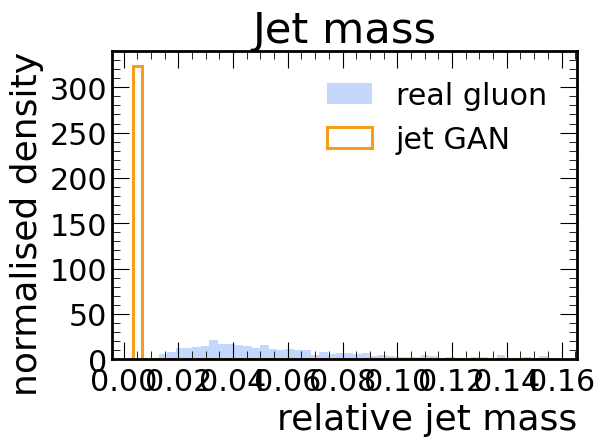

jet-mass W1: 0.0544


0.0544

In [16]:
# cadence:starter
set_seed(SEED)
Gj = JetGenerator().to(device)
Cj = JetCritic().to(device)
ogj = torch.optim.Adam(Gj.parameters(), lr=1e-4, betas=(0.0, 0.9))
ocj = torch.optim.Adam(Cj.parameters(), lr=1e-4, betas=(0.0, 0.9))
real_jets = torch.as_tensor(gluon, dtype=torch.float32)
N_CRITIC = 3
for _ in range(20):
    for (real,) in jet_loader:
        real = real.to(device)
        n = real.shape[0]
        for _c in range(N_CRITIC):
            fake = Gj(sample_noise(n)).detach()
            # WGAN-GP critic loss: E[C(fake)] - E[C(real)] + GP
            c_loss = ...
            ocj.zero_grad(); c_loss.backward(); ocj.step()
        gen = Gj(sample_noise(n))
        # generator loss: -E[C(gen)]
        g_loss = ...
        ogj.zero_grad(); g_loss.backward(); ogj.step()

Gj.eval()
with torch.no_grad():
    gen_jets = jet_std.inverse_transform(Gj(sample_noise(512)).cpu().numpy())  # -> physical
plot_jet_mass(gluon[:512], gen_jets, labels=("real gluon", "jet GAN")); plt.show()
mass_w1 = ...
# cadence:end

set_seed(SEED)
Gj = JetGenerator().to(device)
Cj = JetCritic().to(device)
ogj = torch.optim.Adam(Gj.parameters(), lr=1e-4, betas=(0.0, 0.9))
ocj = torch.optim.Adam(Cj.parameters(), lr=1e-4, betas=(0.0, 0.9))
N_CRITIC = 3
for _ in range(20):
    for (real,) in jet_loader:
        real = real.to(device)
        n = real.shape[0]
        for _c in range(N_CRITIC):
            fake = Gj(sample_noise(n)).detach()
            c_loss = (Cj(fake).mean() - Cj(real).mean()
                      + jet_gradient_penalty(Cj, real, fake))
            ocj.zero_grad(); c_loss.backward(); ocj.step()
        gen = Gj(sample_noise(n))
        g_loss = -Cj(gen).mean()
        ogj.zero_grad(); g_loss.backward(); ogj.step()

Gj.eval()
with torch.no_grad():
    gen_jets = jet_std.inverse_transform(Gj(sample_noise(512)).cpu().numpy())  # -> physical
plot_jet_mass(gluon[:512], gen_jets, labels=("real gluon", "jet GAN")); plt.show()
mass_w1 = round(jet_mass_w1(gluon[:512], gen_jets), 4)
print("jet-mass W1:", mass_w1)

mass_w1

In [ ]:
# Generated jets as event displays, and overlaid on real gluon jets (same axes,
# different colours) — GANs often make them a touch too uniform / too narrow.
plot_jets(gen_jets[:3], titles=[f"GAN jet {i}" for i in range(3)]); plt.show()
plot_jet_overlay(gluon[:3], gen_jets[:3], n=3, labels=("real gluon", "GAN jet")); plt.show()

In [17]:
import numpy as np
def stats(jets, name):
    j = np.asarray(jets); m = j[..., 2] > 0
    print(f"{name:10} | eta std {j[...,0][m].std():.3f}  phi std {j[...,1][m].std():.3f}  "
          f"lead-pt {j[...,2].max(1).mean():.3f}  mult {m.sum(1).mean():.1f}")
stats(gluon[:512], "real")
stats(gen_jets,    "generated")    # or recon_g in notebook 01

real       | eta std 0.080  phi std 0.076  lead-pt 0.182  mult 29.9
generated  | eta std 0.057  phi std 0.038  lead-pt 0.035  mult 30.0


### Exercise 5 — Which features fail, and where?

Two quick conceptual answers based on what you've seen.

First, in **one word**, which end of the jet-mass distribution does the GAN most
struggle to reproduce — the `"bulk"` or the `"tail"`? Set `failure_region`.

Then build a short **list** `gan_failure_modes` of the *named* GAN pathologies we
met in this notebook, in the order we met them: the diversity collapse, then the
training-stability cure. Use the lowercase strings `"mode collapse"` and
`"wgan-gp"`.

In [ ]:
# cadence:starter
# answer: string
failure_region = ...        # "bulk" or "tail"

# (also build this list — only `failure_region` is graded as the answer)
gan_failure_modes = ...     # ["mode collapse", "wgan-gp"]
# cadence:end

failure_region = "tail"
gan_failure_modes = ["mode collapse", "wgan-gp"]
print(failure_region, gan_failure_modes)

failure_region

## Recap

- A GAN is an **adversarial game**: generator vs discriminator/critic.
- **Mode collapse** is the signature failure — the generator covers only a few
  data modes (we *measured* it by snapping samples to nearest data modes).
- **WGAN-GP** — a 1-Lipschitz critic enforced by a **gradient penalty** — gives
  smooth gradients and restores diversity.
- On jets, a **DeepSets generator + critic** matches the bulk of the jet-mass
  spine but **drops the high-mass tail**, the same hard region the VAE missed in
  01 — a story we'll revisit with diffusion (03, 05).

## Generate the cadence notebooks

Run this **after** *Run All* above, so every exercise's answer value is in the kernel. `%cadence_autoregister` auto-detects each `##`-headed exercise, registers a checkpoint from the cell's final value, and writes `<this>_registered.ipynb` — which in turn writes the student notebook via the `%cadence_scaffold` cell it appends.

In [ ]:
%cadence_autoregister